In [1]:
# ============================================================
# PHASE 20 — PATHWAY AND NETWORK VALIDATION
# ============================================================
# Goal:
# Strengthen biological validation at pathway/module level.
#
# Why:
# Phase 19 global external gene-set validation was weak after FDR.
# Phase 19B showed no systematic enrichment among external-supported
# negatives, but identified individual hypothesis-generating genes.
#
# Therefore Phase 20 tests whether model rankings recover coherent
# biological modules:
# - Insulin signalling
# - Beta-cell function / insulin secretion
# - Glucose metabolism / transport
# - Incretin / diabetes pharmacology
# - Mitochondrial complex I / OXPHOS
#
# Outputs:
# - Top-N pathway enrichment with random baseline
# - Model-by-pathway heatmap
# - Pathway member rank-distribution tests
# - Curated network module density vs random baseline
# - Top pathway-supported candidate table
# - Manuscript-ready wording
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import itertools
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

pd.set_option("display.max_columns", 250)
pd.set_option("display.max_colwidth", 500)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

import os
from pathlib import Path
import pandas as pd
from google.colab import drive

try:
    drive.mount('/content/drive')
except ValueError:
    print("Drive đã được kết nối từ trước.")

PROJECT_DIR = Path("/content/drive/MyDrive/Project_Protein")

PHASE15_DIR = PROJECT_DIR / "model" / "phase15_biological_literature_support"
PHASE17_DIR = PROJECT_DIR / "model" / "phase17_repeated_cross_validation_robust_benchmark"
PHASE19_DIR = PROJECT_DIR / "model" / "phase19_external_independent_gene_set_validation"
PHASE19B_DIR = PROJECT_DIR / "model" / "phase19b_external_supported_negative_audit"

PHASE20_DIR = PROJECT_DIR / "model" / "phase20_pathway_network_validation"
RESULT_DIR = PHASE20_DIR / "results"
FIGURE_DIR = PHASE20_DIR / "figures"
EXCEL_DIR = PHASE20_DIR / "excel"
REPORT_DIR = PHASE20_DIR / "reports"

for d in [PHASE20_DIR, RESULT_DIR, FIGURE_DIR, EXCEL_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Phase 20 output:", PHASE20_DIR)

Mounted at /content/drive
Phase 20 output: /content/drive/MyDrive/Project_Protein/model/phase20_pathway_network_validation


In [2]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================

def save_df(df, path):
    path = Path(path)
    df.to_csv(path, index=False)
    print("Saved:", path)


def round_numeric_columns(df, digits=5):
    df = df.copy()
    for col in df.columns:
        if pd.api.types.is_float_dtype(df[col]):
            df[col] = df[col].round(digits)
    return df


def clean_gene_symbol(x):
    if pd.isna(x):
        return None
    s = str(x).strip().upper()
    if s == "" or s in ["NAN", "NONE", "NULL"]:
        return None
    return s


def empirical_p_value(observed, random_values, alternative="greater"):
    random_values = np.asarray(random_values)

    if alternative == "greater":
        return (np.sum(random_values >= observed) + 1) / (len(random_values) + 1)

    if alternative == "less":
        return (np.sum(random_values <= observed) + 1) / (len(random_values) + 1)

    raise ValueError("alternative must be greater or less")


def safe_mannwhitneyu(a, b, alternative="two-sided"):
    try:
        stat, p = mannwhitneyu(a, b, alternative=alternative)
        return stat, p
    except Exception:
        return np.nan, np.nan


def bootstrap_ci_mean(values, n_boot=3000, seed=42, ci=95):
    rng_local = np.random.default_rng(seed)
    values = np.asarray(values, dtype=float)

    boots = []
    for _ in range(n_boot):
        boots.append(np.mean(rng_local.choice(values, size=len(values), replace=True)))

    alpha = (100 - ci) / 2
    return (
        float(np.percentile(boots, alpha)),
        float(np.percentile(boots, 100 - alpha))
    )


def wrap_label(s, width=18):
    import textwrap
    return "\n".join(textwrap.wrap(str(s), width=width))


def get_model_display(model_name):
    mapping = {
        "Genomic_only_K3K4Basic": "Genomic-only",
        "Protein_only_ProtBERT_SW": "Protein-only",
        "Handcrafted_multimodal": "Handcrafted multimodal",
        "DNABERT2_multimodal": "DNABERT-2 multimodal"
    }
    return mapping.get(model_name, model_name)

In [3]:
# ============================================================
# LOAD RANKING AND EVIDENCE FILES
# ============================================================

gene_rank_path = PHASE19_DIR / "results" / "phase19_gene_level_oof_rankings_by_model.csv"
consensus_path = PHASE19_DIR / "results" / "phase19_consensus_gene_ranking_across_models.csv"
external_gene_set_path = PHASE19_DIR / "results" / "phase19_external_gene_set_long.csv"
priority_negative_path = PHASE19B_DIR / "results" / "phase19b_high_priority_external_supported_negative_relabel_candidates.csv"

assert gene_rank_path.exists(), f"Missing: {gene_rank_path}"
assert consensus_path.exists(), f"Missing: {consensus_path}"

gene_rank_df = pd.read_csv(gene_rank_path)
consensus_df = pd.read_csv(consensus_path)

if external_gene_set_path.exists():
    external_gene_set_df = pd.read_csv(external_gene_set_path)
else:
    external_gene_set_df = pd.DataFrame()

if priority_negative_path.exists():
    priority_negative_df = pd.read_csv(priority_negative_path)
else:
    priority_negative_df = pd.DataFrame()

gene_rank_df["gene_symbol"] = gene_rank_df["gene_symbol"].apply(clean_gene_symbol)
consensus_df["gene_symbol"] = consensus_df["gene_symbol"].apply(clean_gene_symbol)

display(gene_rank_df.head())
display(consensus_df.head())

print("Models:", gene_rank_df["model_name"].unique())
print("Candidate universe genes:", consensus_df["gene_symbol"].nunique())

,sample_index,gene_symbol,true_label,mean_oof_score,sd_oof_score,n_oof_predictions,model_name,rank_desc,percentile_rank,display_name
0,386,ATP4B,1,0.897893,0.018568,5,DNABERT2_multimodal,1,1.000000,DNABERT-2 multimodal
1,1701,GRM8,1,0.892079,0.013946,5,DNABERT2_multimodal,2,0.999446,DNABERT-2 multimodal
2,21,NEXMIF,0,0.890804,0.024677,5,DNABERT2_multimodal,3,0.998892,DNABERT-2 multimodal
3,479,HAUS6,0,0.889759,0.007953,5,DNABERT2_multimodal,4,0.998338,DNABERT-2 multimodal
4,454,ZC3H13,1,0.881700,0.005782,5,DNABERT2_multimodal,5,0.997784,DNABERT-2 multimodal


,sample_index,gene_symbol,true_label,mean_percentile_rank,sd_percentile_rank,mean_rank,best_rank,consensus_rank,external_sets,n_external_sets,is_external_supported
0,386,ATP4B,1,0.995984,0.004687,8.25,1,1,NaN,0,False
1,560,VDR,1,0.991274,0.008776,16.75,1,2,NaN,0,False
2,454,ZC3H13,1,0.987950,0.011989,22.75,4,3,NaN,0,False
3,878,B4GALNT1,1,0.984626,0.015256,28.75,14,4,NaN,0,False
4,389,CACNA2D3,1,0.981025,0.018532,35.25,7,5,NaN,0,False


Models: ['DNABERT2_multimodal' 'Genomic_only_K3K4Basic' 'Handcrafted_multimodal'
 'Protein_only_ProtBERT_SW']
Candidate universe genes: 1806


In [4]:
# ============================================================
# DEFINE CURATED PATHWAY MODULES
# ============================================================
# These are conservative, manuscript-friendly gene sets.
# They combine literature-supported T2D themes with pathway-level modules.
# ============================================================

curated_pathways = {
    "Insulin_signalling": [
        "INSR", "IRS1", "IRS2", "PIK3R1", "AKT2", "PTPN1",
        "GRB14", "PPARG", "FOXO1", "GSK3B", "TBC1D4"
    ],

    "Beta_cell_function_development": [
        "PDX1", "NEUROD1", "MAFA", "NKX6-1", "NKX2-2", "PAX4",
        "PAX6", "ISL1", "HNF1A", "HNF1B", "HNF4A", "GLIS3",
        "GCK", "INS", "IAPP", "SLC30A8", "PCSK1", "MTNR1B",
        "CACNA1D", "GAD1"
    ],

    "Insulin_secretion_KATP_Ca": [
        "KCNJ11", "ABCC8", "CACNA1D", "GCK", "SLC30A8",
        "PCSK1", "INS", "IAPP", "GLP1R", "GIPR"
    ],

    "Glucose_metabolism_transport": [
        "GCK", "GCKR", "HK1", "HK2", "G6PC2", "PCK1",
        "SLC2A2", "SLC2A4", "SLC5A1", "SLC5A2",
        "INSR", "IRS1", "IRS2", "AKT2"
    ],

    "Incretin_diabetes_pharmacology": [
        "DPP4", "GLP1R", "GIPR", "SLC5A2", "PPARG",
        "KCNJ11", "ABCC8", "INSR", "GCK", "MGAM"
    ],

    "Known_T2D_GWAS_loci": [
        "TCF7L2", "PPARG", "KCNJ11", "SLC30A8", "HHEX",
        "CDKAL1", "CDKN2A", "CDKN2B", "IGF2BP2", "FTO",
        "WFS1", "MTNR1B", "JAZF1", "CDC123", "CAMK1D",
        "TSPAN8", "LGR5", "THADA", "ADAMTS9", "NOTCH2",
        "IRS1", "KCNQ1", "PROX1", "GCK", "GCKR", "GIPR",
        "ADCY5", "GLIS3", "MAEA", "INSR", "DUSP9",
        "HMGA2", "GRB14", "TP53INP1"
    ],

    "Mitochondrial_complex_I_OXPHOS": [
        "NDUFA1", "NDUFA2", "NDUFA3", "NDUFA4", "NDUFA5",
        "NDUFA6", "NDUFA7", "NDUFA8", "NDUFA9", "NDUFA10",
        "NDUFA11", "NDUFA12", "NDUFA13",
        "NDUFB1", "NDUFB2", "NDUFB3", "NDUFB4", "NDUFB5",
        "NDUFB6", "NDUFB7", "NDUFB8", "NDUFB9", "NDUFB10",
        "NDUFB11",
        "NDUFS1", "NDUFS2", "NDUFS3", "NDUFS4", "NDUFS5",
        "NDUFS6", "NDUFS7", "NDUFS8",
        "NDUFV1", "NDUFV2", "NDUFV3"
    ]
}

# Clean and restrict to candidate universe
candidate_universe = set(consensus_df["gene_symbol"].dropna().astype(str).tolist())

pathway_records = []

for pathway, genes in curated_pathways.items():
    genes_clean = sorted(set([clean_gene_symbol(g) for g in genes if clean_gene_symbol(g)]))

    for g in genes_clean:
        pathway_records.append({
            "pathway": pathway,
            "gene_symbol": g,
            "in_candidate_universe": g in candidate_universe
        })

pathway_gene_df = pd.DataFrame(pathway_records).drop_duplicates()

pathway_coverage_df = (
    pathway_gene_df
    .groupby("pathway", as_index=False)
    .agg(
        n_pathway_genes=("gene_symbol", "nunique"),
        n_in_candidate_universe=("in_candidate_universe", "sum"),
        genes_in_universe=("gene_symbol", lambda x: "; ".join([g for g in sorted(set(x)) if g in candidate_universe]))
    )
)

pathway_coverage_df["coverage_rate"] = (
    pathway_coverage_df["n_in_candidate_universe"] /
    pathway_coverage_df["n_pathway_genes"]
)

pathway_coverage_df = round_numeric_columns(pathway_coverage_df, 4)

display(pathway_coverage_df)

save_df(pathway_gene_df, RESULT_DIR / "phase20_curated_pathway_gene_sets_long.csv")
save_df(pathway_coverage_df, RESULT_DIR / "phase20_curated_pathway_coverage.csv")

,pathway,n_pathway_genes,n_in_candidate_universe,genes_in_universe,coverage_rate
0,Beta_cell_function_development,20,16,CACNA1D; GAD1; GCK; GLIS3; HNF1A; HNF1B; HNF4A; INS; ISL1; MTNR1B; NEUROD1; NKX6-1; PAX4; PCSK1; PDX1; SLC30A8,0.8000
1,Glucose_metabolism_transport,14,11,AKT2; G6PC2; GCK; GCKR; HK1; INSR; IRS1; IRS2; SLC2A2; SLC5A1; SLC5A2,0.7857
2,Incretin_diabetes_pharmacology,10,10,ABCC8; DPP4; GCK; GIPR; GLP1R; INSR; KCNJ11; MGAM; PPARG; SLC5A2,1.0000
3,Insulin_secretion_KATP_Ca,10,9,ABCC8; CACNA1D; GCK; GIPR; GLP1R; INS; KCNJ11; PCSK1; SLC30A8,0.9000
4,Insulin_signalling,11,8,AKT2; GRB14; INSR; IRS1; IRS2; PIK3R1; PPARG; TBC1D4,0.7273
5,Known_T2D_GWAS_loci,34,32,ADAMTS9; ADCY5; CAMK1D; CDC123; CDKAL1; CDKN2B; DUSP9; FTO; GCK; GCKR; GIPR; GLIS3; GRB14; HHEX; HMGA2; IGF2BP2; INSR; IRS1; JAZF1; KCNJ11; KCNQ1; MAEA; MTNR1B; NOTCH2; PPARG; PROX1; SLC30A8; TCF7L2; THADA; TP53INP1; TSPAN8; WFS1,0.9412
6,Mitochondrial_complex_I_OXPHOS,35,34,NDUFA1; NDUFA10; NDUFA11; NDUFA12; NDUFA13; NDUFA2; NDUFA3; NDUFA5; NDUFA6; NDUFA7; NDUFA8; NDUFA9; NDUFB1; NDUFB10; NDUFB11; NDUFB2; NDUFB3; NDUFB4; NDUFB5; NDUFB6; NDUFB7; NDUFB8; NDUFB9; NDUFS1; NDUFS2; NDUFS3; NDUFS4; NDUFS5; NDUFS6; NDUFS7; NDUFS8; NDUFV1; NDUFV2; NDUFV3,0.9714


Saved: /content/drive/MyDrive/Project_Protein/model/phase20_pathway_network_validation/results/phase20_curated_pathway_gene_sets_long.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase20_pathway_network_validation/results/phase20_curated_pathway_coverage.csv


In [5]:
# ============================================================
# TOP-N PATHWAY ENRICHMENT WITH RANDOM BASELINE
# ============================================================

TOP_N_LIST = [25, 50, 100, 150, 200]
N_RANDOM = 5000

topn_records = []

for model_name, sub_model in gene_rank_df.groupby("model_name"):
    sub_model = sub_model.sort_values("rank_desc").reset_index(drop=True)

    universe_genes = sub_model["gene_symbol"].dropna().astype(str).unique().tolist()
    universe_set = set(universe_genes)

    for pathway, p_df in pathway_gene_df.groupby("pathway"):
        pathway_genes = set(
            p_df.loc[p_df["in_candidate_universe"], "gene_symbol"].astype(str).tolist()
        ).intersection(universe_set)

        if len(pathway_genes) == 0:
            continue

        for top_n in TOP_N_LIST:
            top_genes = set(sub_model.head(top_n)["gene_symbol"].astype(str).tolist())
            observed = len(top_genes.intersection(pathway_genes))

            random_counts = []
            for _ in range(N_RANDOM):
                rand_genes = set(rng.choice(universe_genes, size=top_n, replace=False))
                random_counts.append(len(rand_genes.intersection(pathway_genes)))

            random_counts = np.asarray(random_counts)
            random_mean = random_counts.mean()
            random_sd = random_counts.std(ddof=1)

            p_emp = empirical_p_value(observed, random_counts, alternative="greater")
            fold = observed / random_mean if random_mean > 0 else np.nan

            topn_records.append({
                "model_name": model_name,
                "display_name": get_model_display(model_name),
                "pathway": pathway,
                "top_n": top_n,
                "observed_overlap": observed,
                "pathway_genes_in_universe": len(pathway_genes),
                "random_mean": random_mean,
                "random_sd": random_sd,
                "fold_enrichment_vs_random": fold,
                "empirical_p": p_emp,
                "overlap_genes": "; ".join(sorted(top_genes.intersection(pathway_genes)))
            })

topn_pathway_df = pd.DataFrame(topn_records)

topn_pathway_df["empirical_bh_fdr_global"] = multipletests(
    topn_pathway_df["empirical_p"],
    method="fdr_bh"
)[1]

topn_pathway_df["empirical_bh_fdr_within_topn"] = np.nan

for top_n, sub in topn_pathway_df.groupby("top_n"):
    idx = sub.index
    topn_pathway_df.loc[idx, "empirical_bh_fdr_within_topn"] = multipletests(
        sub["empirical_p"],
        method="fdr_bh"
    )[1]

topn_pathway_df = round_numeric_columns(topn_pathway_df, 5)

display(topn_pathway_df.head(50))

save_df(topn_pathway_df, RESULT_DIR / "phase20_topn_pathway_enrichment_random_baseline.csv")

,model_name,display_name,pathway,top_n,observed_overlap,pathway_genes_in_universe,random_mean,random_sd,fold_enrichment_vs_random,empirical_p,overlap_genes,empirical_bh_fdr_global,empirical_bh_fdr_within_topn
0,DNABERT2_multimodal,DNABERT-2 multimodal,Beta_cell_function_development,25,1,16,0.2210,0.46065,4.52489,0.20196,NKX6-1,1.0,1.00000
1,DNABERT2_multimodal,DNABERT-2 multimodal,Beta_cell_function_development,50,1,16,0.4444,0.66015,2.25023,0.36113,NKX6-1,1.0,1.00000
2,DNABERT2_multimodal,DNABERT-2 multimodal,Beta_cell_function_development,100,1,16,0.8884,0.92115,1.12562,0.59728,NKX6-1,1.0,1.00000
3,DNABERT2_multimodal,DNABERT-2 multimodal,Beta_cell_function_development,150,1,16,1.3156,1.08436,0.76011,0.74925,NKX6-1,1.0,1.00000
4,DNABERT2_multimodal,DNABERT-2 multimodal,Beta_cell_function_development,200,1,16,1.7436,1.24666,0.57353,0.84323,NKX6-1,1.0,1.00000
5,DNABERT2_multimodal,DNABERT-2 multimodal,Glucose_metabolism_transport,25,0,11,0.1570,0.39190,0.00000,1.00000,,1.0,1.00000
6,DNABERT2_multimodal,DNABERT-2 multimodal,Glucose_metabolism_transport,50,1,11,0.3186,0.55277,3.13873,0.27714,GCKR,1.0,1.00000
7,DNABERT2_multimodal,DNABERT-2 multimodal,Glucose_metabolism_transport,100,1,11,0.5830,0.74082,1.71527,0.45231,GCKR,1.0,1.00000
8,DNABERT2_multimodal,DNABERT-2 multimodal,Glucose_metabolism_transport,150,1,11,0.9130,0.90310,1.09529,0.62008,GCKR,1.0,1.00000
9,DNABERT2_multimodal,DNABERT-2 multimodal,Glucose_metabolism_transport,200,1,11,1.2270,1.04560,0.81500,0.72685,GCKR,1.0,0.98194


Saved: /content/drive/MyDrive/Project_Protein/model/phase20_pathway_network_validation/results/phase20_topn_pathway_enrichment_random_baseline.csv


In [6]:
# ============================================================
# PATHWAY RANK-DISTRIBUTION TESTS
# ============================================================
# Question:
# Are pathway genes ranked higher than non-pathway genes?
# ============================================================

rank_test_records = []

for model_name, sub_model in gene_rank_df.groupby("model_name"):
    universe_genes = set(sub_model["gene_symbol"].dropna().astype(str).tolist())

    for pathway, p_df in pathway_gene_df.groupby("pathway"):
        pathway_genes = set(
            p_df.loc[p_df["in_candidate_universe"], "gene_symbol"].astype(str).tolist()
        ).intersection(universe_genes)

        if len(pathway_genes) < 2:
            continue

        tmp = sub_model.copy()
        tmp["is_pathway_gene"] = tmp["gene_symbol"].isin(pathway_genes)

        pathway_scores = tmp.loc[tmp["is_pathway_gene"], "mean_oof_score"].values
        non_scores = tmp.loc[~tmp["is_pathway_gene"], "mean_oof_score"].values

        pathway_ranks = tmp.loc[tmp["is_pathway_gene"], "rank_desc"].values
        non_ranks = tmp.loc[~tmp["is_pathway_gene"], "rank_desc"].values

        stat_score, p_score = safe_mannwhitneyu(
            pathway_scores,
            non_scores,
            alternative="greater"
        )

        stat_rank, p_rank = safe_mannwhitneyu(
            -pathway_ranks,
            -non_ranks,
            alternative="greater"
        )

        rank_test_records.append({
            "model_name": model_name,
            "display_name": get_model_display(model_name),
            "pathway": pathway,
            "n_pathway_genes_in_universe": len(pathway_genes),
            "mean_score_pathway": np.mean(pathway_scores),
            "mean_score_non_pathway": np.mean(non_scores),
            "delta_mean_score": np.mean(pathway_scores) - np.mean(non_scores),
            "median_rank_pathway": np.median(pathway_ranks),
            "median_rank_non_pathway": np.median(non_ranks),
            "mannwhitney_score_greater_p": p_score,
            "mannwhitney_rank_greater_p": p_rank,
            "pathway_genes_in_universe": "; ".join(sorted(pathway_genes))
        })

pathway_rank_test_df = pd.DataFrame(rank_test_records)

pathway_rank_test_df["score_bh_fdr_global"] = multipletests(
    pathway_rank_test_df["mannwhitney_score_greater_p"],
    method="fdr_bh"
)[1]

pathway_rank_test_df["rank_bh_fdr_global"] = multipletests(
    pathway_rank_test_df["mannwhitney_rank_greater_p"],
    method="fdr_bh"
)[1]

pathway_rank_test_df = round_numeric_columns(pathway_rank_test_df, 5)

display(pathway_rank_test_df)

save_df(pathway_rank_test_df, RESULT_DIR / "phase20_pathway_rank_distribution_tests.csv")

,model_name,display_name,pathway,n_pathway_genes_in_universe,mean_score_pathway,mean_score_non_pathway,delta_mean_score,median_rank_pathway,median_rank_non_pathway,mannwhitney_score_greater_p,mannwhitney_rank_greater_p,pathway_genes_in_universe,score_bh_fdr_global,rank_bh_fdr_global
0,DNABERT2_multimodal,DNABERT-2 multimodal,Beta_cell_function_development,16,0.44627,0.50012,-0.05385,1127.0,900.5,0.87095,0.87095,CACNA1D; GAD1; GCK; GLIS3; HNF1A; HNF1B; HNF4A; INS; ISL1; MTNR1B; NEUROD1; NKX6-1; PAX4; PCSK1; PDX1; SLC30A8,0.89667,0.89667
1,DNABERT2_multimodal,DNABERT-2 multimodal,Glucose_metabolism_transport,11,0.53713,0.49941,0.03772,911.0,903.0,0.26403,0.26403,AKT2; G6PC2; GCK; GCKR; HK1; INSR; IRS1; IRS2; SLC2A2; SLC5A1; SLC5A2,0.64493,0.64737
2,DNABERT2_multimodal,DNABERT-2 multimodal,Incretin_diabetes_pharmacology,10,0.53832,0.49943,0.03889,552.5,904.5,0.25246,0.25246,ABCC8; DPP4; GCK; GIPR; GLP1R; INSR; KCNJ11; MGAM; PPARG; SLC5A2,0.64493,0.64737
3,DNABERT2_multimodal,DNABERT-2 multimodal,Insulin_secretion_KATP_Ca,9,0.45979,0.49984,-0.04005,1129.0,903.0,0.72289,0.72289,ABCC8; CACNA1D; GCK; GIPR; GLP1R; INS; KCNJ11; PCSK1; SLC30A8,0.86382,0.86382
4,DNABERT2_multimodal,DNABERT-2 multimodal,Insulin_signalling,8,0.50646,0.49961,0.00685,767.0,903.5,0.46984,0.46984,AKT2; GRB14; INSR; IRS1; IRS2; PIK3R1; PPARG; TBC1D4,0.65778,0.65778
5,DNABERT2_multimodal,DNABERT-2 multimodal,Known_T2D_GWAS_loci,32,0.51327,0.49940,0.01388,915.0,903.5,0.33730,0.33730,ADAMTS9; ADCY5; CAMK1D; CDC123; CDKAL1; CDKN2B; DUSP9; FTO; GCK; GCKR; GIPR; GLIS3; GRB14; HHEX; HMGA2; IGF2BP2; INSR; IRS1; JAZF1; KCNJ11; KCNQ1; MAEA; MTNR1B; NOTCH2; PPARG; PROX1; SLC30A8; TCF7L2; THADA; TP53INP1; TSPAN8; WFS1,0.64493,0.64737
6,DNABERT2_multimodal,DNABERT-2 multimodal,Mitochondrial_complex_I_OXPHOS,34,0.54372,0.49880,0.04492,665.5,907.5,0.09267,0.09267,NDUFA1; NDUFA10; NDUFA11; NDUFA12; NDUFA13; NDUFA2; NDUFA3; NDUFA5; NDUFA6; NDUFA7; NDUFA8; NDUFA9; NDUFB1; NDUFB10; NDUFB11; NDUFB2; NDUFB3; NDUFB4; NDUFB5; NDUFB6; NDUFB7; NDUFB8; NDUFB9; NDUFS1; NDUFS2; NDUFS3; NDUFS4; NDUFS5; NDUFS6; NDUFS7; NDUFS8; NDUFV1; NDUFV2; NDUFV3,0.64493,0.64737
7,Genomic_only_K3K4Basic,Genomic-only,Beta_cell_function_development,16,0.51335,0.50074,0.01262,681.5,905.5,0.24312,0.24320,CACNA1D; GAD1; GCK; GLIS3; HNF1A; HNF1B; HNF4A; INS; ISL1; MTNR1B; NEUROD1; NKX6-1; PAX4; PCSK1; PDX1; SLC30A8,0.64493,0.64737
8,Genomic_only_K3K4Basic,Genomic-only,Glucose_metabolism_transport,11,0.50027,0.50085,-0.00058,777.0,905.0,0.39572,0.39572,AKT2; G6PC2; GCK; GCKR; HK1; INSR; IRS1; IRS2; SLC2A2; SLC5A1; SLC5A2,0.64493,0.64737
9,Genomic_only_K3K4Basic,Genomic-only,Incretin_diabetes_pharmacology,10,0.51659,0.50076,0.01583,702.0,905.5,0.25951,0.25951,ABCC8; DPP4; GCK; GIPR; GLP1R; INSR; KCNJ11; MGAM; PPARG; SLC5A2,0.64493,0.64737


Saved: /content/drive/MyDrive/Project_Protein/model/phase20_pathway_network_validation/results/phase20_pathway_rank_distribution_tests.csv


In [7]:
# ============================================================
# BUILD CURATED BIOLOGICAL NETWORK
# ============================================================
# This is not a full STRING network. It is a conservative curated
# pathway-module network for manuscript-level supportive validation.
#
# Each edge means: same pathway/module membership or direct functional pair.
# ============================================================

edge_records = []

def add_clique_edges(genes, module_name, edge_type="same_module"):
    genes = sorted(set([clean_gene_symbol(g) for g in genes if clean_gene_symbol(g)]))
    for a, b in itertools.combinations(genes, 2):
        edge_records.append({
            "gene_a": a,
            "gene_b": b,
            "module": module_name,
            "edge_type": edge_type
        })

def add_pair(a, b, module_name, edge_type="functional_pair"):
    edge_records.append({
        "gene_a": clean_gene_symbol(a),
        "gene_b": clean_gene_symbol(b),
        "module": module_name,
        "edge_type": edge_type
    })

# Conservative cliques/modules
add_clique_edges(["INSR", "IRS1", "IRS2", "PIK3R1", "AKT2", "PTPN1", "GRB14"], "Insulin_signalling")
add_clique_edges(["PDX1", "NEUROD1", "MAFA", "NKX6-1", "NKX2-2", "PAX4", "PAX6", "ISL1"], "Beta_cell_transcription")
add_clique_edges(["KCNJ11", "ABCC8", "CACNA1D", "GCK", "SLC30A8", "INS", "PCSK1"], "Insulin_secretion")
add_clique_edges(["DPP4", "GLP1R", "GIPR", "SLC5A2", "PPARG", "MGAM"], "Diabetes_pharmacology")

# NDUF complex I module
nduf_genes = curated_pathways["Mitochondrial_complex_I_OXPHOS"]
add_clique_edges(nduf_genes, "Mitochondrial_complex_I", edge_type="complex_I_module")

# Specific pairs
add_pair("KCNJ11", "ABCC8", "KATP_channel")
add_pair("DPP4", "GLP1R", "Incretin_axis")
add_pair("DPP4", "GIPR", "Incretin_axis")
add_pair("INSR", "IRS1", "Insulin_receptor_axis")
add_pair("INSR", "IRS2", "Insulin_receptor_axis")
add_pair("PDX1", "INS", "Beta_cell_insulin_regulation")
add_pair("NEUROD1", "INS", "Beta_cell_insulin_regulation")

network_edges_df = pd.DataFrame(edge_records).drop_duplicates()

# Keep only edges where both genes are in candidate universe
network_edges_df["a_in_universe"] = network_edges_df["gene_a"].isin(candidate_universe)
network_edges_df["b_in_universe"] = network_edges_df["gene_b"].isin(candidate_universe)
network_edges_universe_df = network_edges_df[
    network_edges_df["a_in_universe"] & network_edges_df["b_in_universe"]
].copy()

display(network_edges_universe_df.head())
display(network_edges_universe_df["module"].value_counts())

save_df(network_edges_df, RESULT_DIR / "phase20_curated_network_edges_all.csv")
save_df(network_edges_universe_df, RESULT_DIR / "phase20_curated_network_edges_in_universe.csv")

,gene_a,gene_b,module,edge_type,a_in_universe,b_in_universe
0,AKT2,GRB14,Insulin_signalling,same_module,True,True
1,AKT2,INSR,Insulin_signalling,same_module,True,True
2,AKT2,IRS1,Insulin_signalling,same_module,True,True
3,AKT2,IRS2,Insulin_signalling,same_module,True,True
4,AKT2,PIK3R1,Insulin_signalling,same_module,True,True


,count
module,
Mitochondrial_complex_I,561
Insulin_secretion,21
Insulin_signalling,15
Diabetes_pharmacology,15
Beta_cell_transcription,10
Incretin_axis,2
Insulin_receptor_axis,2
Beta_cell_insulin_regulation,2
KATP_channel,1


Saved: /content/drive/MyDrive/Project_Protein/model/phase20_pathway_network_validation/results/phase20_curated_network_edges_all.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase20_pathway_network_validation/results/phase20_curated_network_edges_in_universe.csv


In [8]:
# ============================================================
# NETWORK MODULE DENSITY IN TOP-N GENES
# ============================================================
# Question:
# Do top-ranked genes contain more curated network edges/modules
# than random same-size gene sets?
# ============================================================

TOP_N_NETWORK = [50, 100, 150, 200]
N_RANDOM_NETWORK = 3000

network_records = []

edge_pairs = set()
for _, row in network_edges_universe_df.iterrows():
    a, b = sorted([row["gene_a"], row["gene_b"]])
    edge_pairs.add((a, b))

for model_name, sub_model in gene_rank_df.groupby("model_name"):
    sub_model = sub_model.sort_values("rank_desc").reset_index(drop=True)
    universe_genes = sub_model["gene_symbol"].dropna().astype(str).unique().tolist()

    for top_n in TOP_N_NETWORK:
        top_genes = set(sub_model.head(top_n)["gene_symbol"].astype(str).tolist())

        observed_edges = 0
        observed_edge_list = []

        for a, b in edge_pairs:
            if a in top_genes and b in top_genes:
                observed_edges += 1
                observed_edge_list.append(f"{a}-{b}")

        random_edge_counts = []
        for _ in range(N_RANDOM_NETWORK):
            rand_genes = set(rng.choice(universe_genes, size=top_n, replace=False))
            c = 0
            for a, b in edge_pairs:
                if a in rand_genes and b in rand_genes:
                    c += 1
            random_edge_counts.append(c)

        random_edge_counts = np.asarray(random_edge_counts)
        random_mean = random_edge_counts.mean()
        random_sd = random_edge_counts.std(ddof=1)

        p_emp = empirical_p_value(observed_edges, random_edge_counts, alternative="greater")
        fold = observed_edges / random_mean if random_mean > 0 else np.nan

        network_records.append({
            "model_name": model_name,
            "display_name": get_model_display(model_name),
            "top_n": top_n,
            "observed_curated_network_edges": observed_edges,
            "random_mean_edges": random_mean,
            "random_sd_edges": random_sd,
            "fold_enrichment_vs_random": fold,
            "empirical_p": p_emp,
            "observed_edges": "; ".join(observed_edge_list[:100])
        })

network_density_df = pd.DataFrame(network_records)

network_density_df["empirical_bh_fdr_global"] = multipletests(
    network_density_df["empirical_p"],
    method="fdr_bh"
)[1]

network_density_df["empirical_bh_fdr_within_topn"] = np.nan

for top_n, sub in network_density_df.groupby("top_n"):
    idx = sub.index
    network_density_df.loc[idx, "empirical_bh_fdr_within_topn"] = multipletests(
        sub["empirical_p"],
        method="fdr_bh"
    )[1]

network_density_df = round_numeric_columns(network_density_df, 5)

display(network_density_df)

save_df(network_density_df, RESULT_DIR / "phase20_topn_curated_network_density_random_baseline.csv")

,model_name,display_name,top_n,observed_curated_network_edges,random_mean_edges,random_sd_edges,fold_enrichment_vs_random,empirical_p,observed_edges,empirical_bh_fdr_global,empirical_bh_fdr_within_topn
0,DNABERT2_multimodal,DNABERT-2 multimodal,50,0,0.49167,1.10891,0.00000,1.00000,,1.00000,1.00000
1,DNABERT2_multimodal,DNABERT-2 multimodal,100,6,1.85967,2.71498,3.22638,0.11496,NDUFA12-NDUFA7; NDUFA7-NDUFB11; NDUFA12-NDUFV1; NDUFA7-NDUFV1; NDUFA12-NDUFB11; NDUFB11-NDUFV1,0.83172,0.45985
2,DNABERT2_multimodal,DNABERT-2 multimodal,150,10,4.40267,4.74946,2.27135,0.15595,NDUFA12-NDUFA7; NDUFA7-NDUFB11; NDUFA12-NDUFV1; NDUFA12-NDUFV2; NDUFA7-NDUFV1; NDUFA12-NDUFB11; NDUFV1-NDUFV2; NDUFA7-NDUFV2; NDUFB11-NDUFV1; NDUFB11-NDUFV2,0.83172,0.56814
3,DNABERT2_multimodal,DNABERT-2 multimodal,200,21,7.72600,7.05239,2.71809,0.07731,NDUFA12-NDUFA7; NDUFA7-NDUFB11; NDUFA7-NDUFB10; NDUFB10-NDUFS6; NDUFB10-NDUFV1; NDUFS6-NDUFV1; NDUFB10-NDUFB11; NDUFS6-NDUFV2; NDUFA12-NDUFS6; NDUFA12-NDUFV1; NDUFA12-NDUFV2; NDUFA7-NDUFS6; NDUFA7-NDUFV1; NDUFB11-NDUFS6; NDUFA12-NDUFB11; NDUFV1-NDUFV2; NDUFA7-NDUFV2; NDUFA12-NDUFB10; NDUFB11-NDUFV1; NDUFB11-NDUFV2; NDUFB10-NDUFV2,0.83172,0.30923
4,Genomic_only_K3K4Basic,Genomic-only,50,0,0.46433,1.02000,0.00000,1.00000,,1.00000,1.00000
5,Genomic_only_K3K4Basic,Genomic-only,100,0,1.85000,2.82857,0.00000,1.00000,,1.00000,1.00000
6,Genomic_only_K3K4Basic,Genomic-only,150,3,4.37733,5.14105,0.68535,0.56048,NDUFS6-NDUFV1; NDUFA12-NDUFS6; NDUFA12-NDUFV1,1.00000,0.56814
7,Genomic_only_K3K4Basic,Genomic-only,200,6,7.59533,7.11457,0.78996,0.55315,NDUFS6-NDUFV1; NDUFA12-NDUFS4; NDUFA12-NDUFS6; NDUFA12-NDUFV1; NDUFS4-NDUFS6; NDUFS4-NDUFV1,1.00000,0.55448
8,Handcrafted_multimodal,Handcrafted multimodal,50,0,0.47367,1.08645,0.00000,1.00000,,1.00000,1.00000
9,Handcrafted_multimodal,Handcrafted multimodal,100,1,1.89133,2.71416,0.52873,0.63779,NDUFB11-NDUFV1,1.00000,1.00000


Saved: /content/drive/MyDrive/Project_Protein/model/phase20_pathway_network_validation/results/phase20_topn_curated_network_density_random_baseline.csv


In [9]:
# ============================================================
# PATHWAY-SUPPORTED CANDIDATE TABLE
# ============================================================

# Add pathway annotations to consensus ranking
gene_to_pathways = (
    pathway_gene_df[pathway_gene_df["in_candidate_universe"] == True]
    .groupby("gene_symbol", as_index=False)
    .agg(
        n_curated_pathways=("pathway", "nunique"),
        curated_pathways=("pathway", lambda x: "; ".join(sorted(set(map(str, x)))))
    )
)

pathway_candidate_df = consensus_df.merge(
    gene_to_pathways,
    on="gene_symbol",
    how="left"
)

pathway_candidate_df["n_curated_pathways"] = pathway_candidate_df["n_curated_pathways"].fillna(0).astype(int)
pathway_candidate_df["curated_pathways"] = pathway_candidate_df["curated_pathways"].fillna("")
pathway_candidate_df["is_pathway_supported"] = pathway_candidate_df["n_curated_pathways"] > 0

# Add priority-negative audit if available
if not priority_negative_df.empty:
    tmp_priority = priority_negative_df[[
        "gene_symbol",
        "relabel_audit_priority",
        "external_evidence_strength"
    ]].drop_duplicates()

    pathway_candidate_df = pathway_candidate_df.merge(
        tmp_priority,
        on="gene_symbol",
        how="left"
    )
else:
    pathway_candidate_df["relabel_audit_priority"] = ""
    pathway_candidate_df["external_evidence_strength"] = ""

pathway_candidate_df["relabel_audit_priority"] = pathway_candidate_df["relabel_audit_priority"].fillna("")
pathway_candidate_df["external_evidence_strength"] = pathway_candidate_df["external_evidence_strength"].fillna("")

top_pathway_candidates_df = pathway_candidate_df[
    pathway_candidate_df["is_pathway_supported"]
].sort_values("consensus_rank").reset_index(drop=True)

compact_top_pathway_candidates_df = top_pathway_candidates_df[[
    "gene_symbol",
    "true_label",
    "consensus_rank",
    "mean_percentile_rank",
    "best_rank",
    "n_curated_pathways",
    "curated_pathways",
    "relabel_audit_priority",
    "external_evidence_strength"
]].head(50).copy()

compact_top_pathway_candidates_df = round_numeric_columns(compact_top_pathway_candidates_df, 5)

display(compact_top_pathway_candidates_df)

save_df(pathway_candidate_df, RESULT_DIR / "phase20_all_genes_with_pathway_annotations.csv")
save_df(compact_top_pathway_candidates_df, RESULT_DIR / "phase20_top_pathway_supported_candidates.csv")

,gene_symbol,true_label,consensus_rank,mean_percentile_rank,best_rank,n_curated_pathways,curated_pathways,relabel_audit_priority,external_evidence_strength
0,NDUFV1,0,22,0.95374,28,1,Mitochondrial_complex_I_OXPHOS,high,single_source
1,NDUFS6,1,90,0.90512,120,1,Mitochondrial_complex_I_OXPHOS,,
2,NDUFB11,1,95,0.90125,55,1,Mitochondrial_complex_I_OXPHOS,,
3,NDUFA7,1,107,0.89584,28,1,Mitochondrial_complex_I_OXPHOS,,
4,NKX6-1,1,115,0.89003,23,1,Beta_cell_function_development,,
5,GCKR,1,131,0.87687,6,2,Glucose_metabolism_transport; Known_T2D_GWAS_loci,,
6,MGAM,1,156,0.86150,130,1,Incretin_diabetes_pharmacology,,
7,NDUFA12,0,158,0.85997,30,1,Mitochondrial_complex_I_OXPHOS,high,single_source
8,IRS1,1,159,0.85983,117,3,Glucose_metabolism_transport; Insulin_signalling; Known_T2D_GWAS_loci,,
9,CDC123,1,168,0.85582,48,1,Known_T2D_GWAS_loci,,


Saved: /content/drive/MyDrive/Project_Protein/model/phase20_pathway_network_validation/results/phase20_all_genes_with_pathway_annotations.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase20_pathway_network_validation/results/phase20_top_pathway_supported_candidates.csv


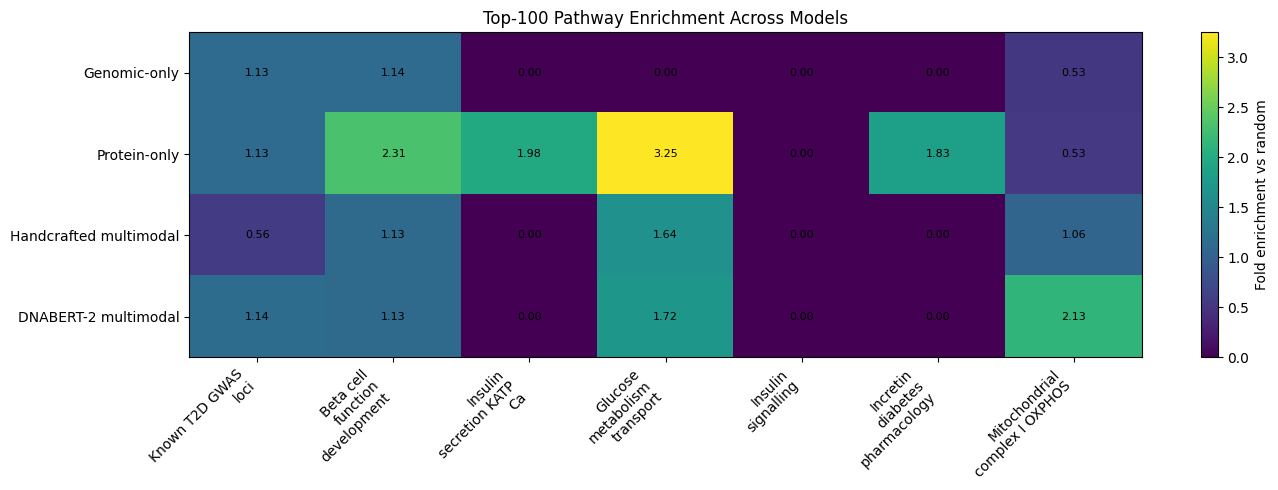

Saved: /content/drive/MyDrive/Project_Protein/model/phase20_pathway_network_validation/figures/phase20_top100_pathway_enrichment_heatmap.png


In [10]:
# ============================================================
# FIGURE 1 — TOP-100 PATHWAY ENRICHMENT HEATMAP
# ============================================================

PLOT_TOP_N = 100

heat_df = topn_pathway_df[topn_pathway_df["top_n"] == PLOT_TOP_N].copy()

model_order = [
    "Genomic-only",
    "Protein-only",
    "Handcrafted multimodal",
    "DNABERT-2 multimodal"
]

pathway_order = [
    "Known_T2D_GWAS_loci",
    "Beta_cell_function_development",
    "Insulin_secretion_KATP_Ca",
    "Glucose_metabolism_transport",
    "Insulin_signalling",
    "Incretin_diabetes_pharmacology",
    "Mitochondrial_complex_I_OXPHOS"
]

heat_pivot = heat_df.pivot_table(
    index="display_name",
    columns="pathway",
    values="fold_enrichment_vs_random"
).reindex(model_order)

heat_pivot = heat_pivot[[p for p in pathway_order if p in heat_pivot.columns]]

plt.figure(figsize=(14, 5))
plt.imshow(heat_pivot.values, aspect="auto")

plt.xticks(
    np.arange(heat_pivot.shape[1]),
    [wrap_label(c.replace("_", " "), 16) for c in heat_pivot.columns],
    rotation=45,
    ha="right"
)
plt.yticks(np.arange(heat_pivot.shape[0]), heat_pivot.index)

plt.colorbar(label="Fold enrichment vs random")
plt.title(f"Top-{PLOT_TOP_N} Pathway Enrichment Across Models")

for i in range(heat_pivot.shape[0]):
    for j in range(heat_pivot.shape[1]):
        val = heat_pivot.values[i, j]
        if not np.isnan(val):
            plt.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)

plt.tight_layout()

out_path = FIGURE_DIR / f"phase20_top{PLOT_TOP_N}_pathway_enrichment_heatmap.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

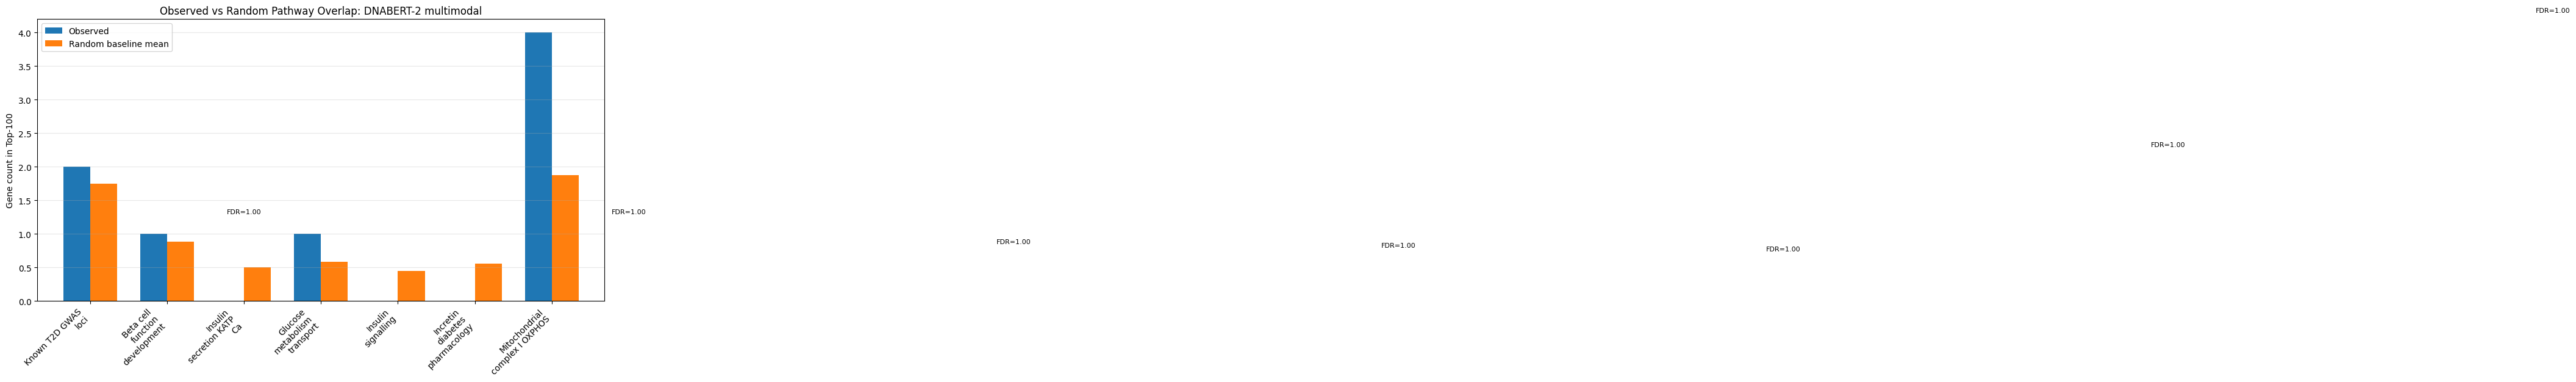

Saved: /content/drive/MyDrive/Project_Protein/model/phase20_pathway_network_validation/figures/phase20_DNABERT-2_multimodal_top100_observed_vs_random_pathway_overlap.png


In [11]:
# ============================================================
# FIGURE 2 — OBSERVED VS RANDOM PATHWAY OVERLAP
# ============================================================

PLOT_MODEL = "DNABERT-2 multimodal"
PLOT_TOP_N = 100

plot_df = topn_pathway_df[
    (topn_pathway_df["display_name"] == PLOT_MODEL) &
    (topn_pathway_df["top_n"] == PLOT_TOP_N)
].copy()

plot_df = plot_df[plot_df["pathway"].isin(pathway_order)].copy()
plot_df["pathway"] = pd.Categorical(plot_df["pathway"], categories=pathway_order, ordered=True)
plot_df = plot_df.sort_values("pathway")

x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, plot_df["observed_overlap"], width=width, label="Observed")
plt.bar(x + width/2, plot_df["random_mean"], width=width, label="Random baseline mean")

plt.xticks(
    x,
    [wrap_label(p.replace("_", " "), 16) for p in plot_df["pathway"]],
    rotation=45,
    ha="right"
)
plt.ylabel(f"Gene count in Top-{PLOT_TOP_N}")
plt.title(f"Observed vs Random Pathway Overlap: {PLOT_MODEL}")
plt.grid(axis="y", alpha=0.3)
plt.legend()

for i, row in plot_df.iterrows():
    plt.text(
        i,
        max(row["observed_overlap"], row["random_mean"]) + 0.3,
        f"FDR={row['empirical_bh_fdr_within_topn']:.2f}",
        ha="center",
        fontsize=8
    )

plt.tight_layout()

out_path = FIGURE_DIR / f"phase20_{PLOT_MODEL.replace(' ', '_')}_top{PLOT_TOP_N}_observed_vs_random_pathway_overlap.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

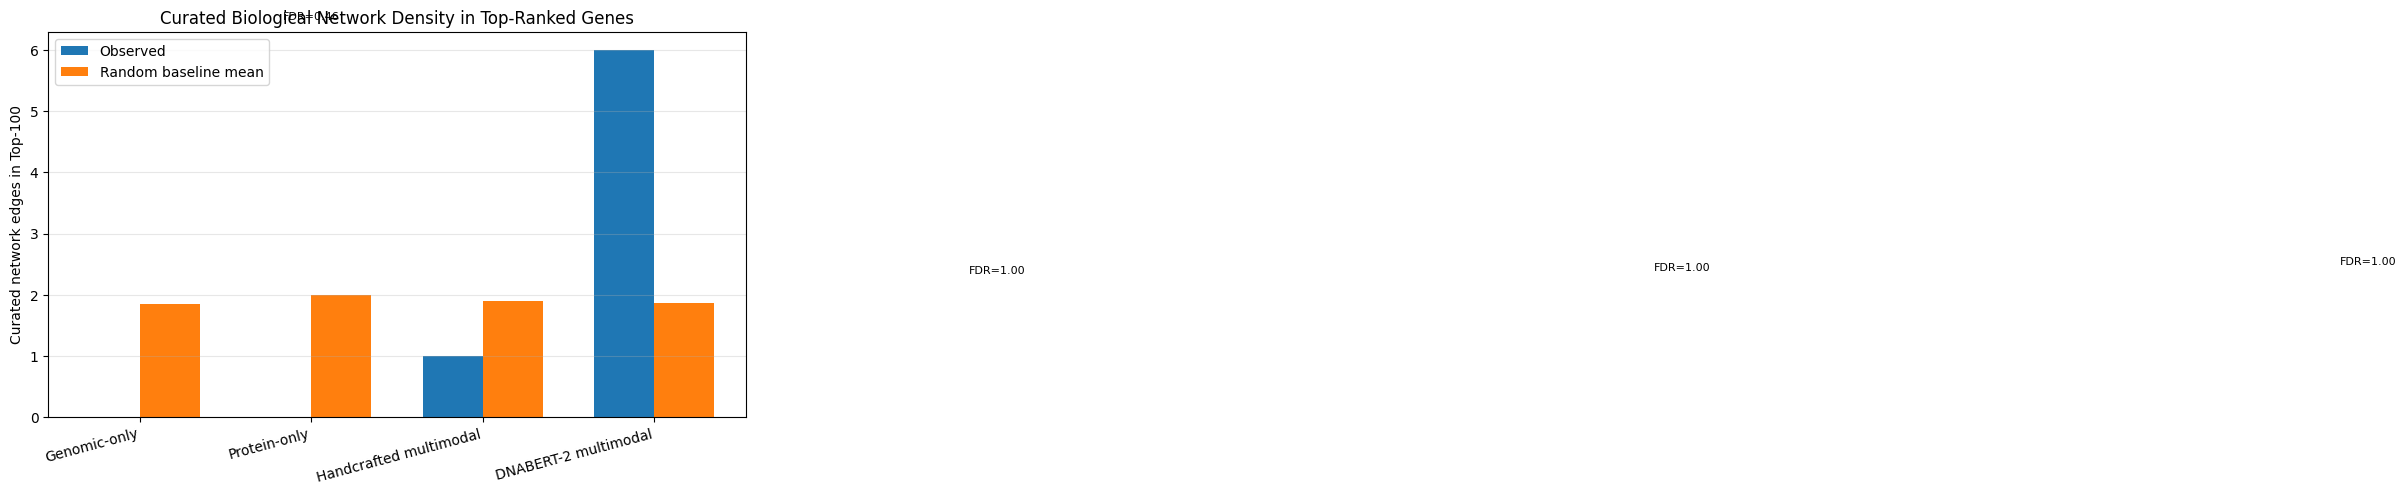

Saved: /content/drive/MyDrive/Project_Protein/model/phase20_pathway_network_validation/figures/phase20_top100_curated_network_density.png


In [12]:
# ============================================================
# FIGURE 3 — CURATED NETWORK DENSITY
# ============================================================

PLOT_TOP_N = 100

plot_df = network_density_df[network_density_df["top_n"] == PLOT_TOP_N].copy()
plot_df["display_name"] = pd.Categorical(plot_df["display_name"], categories=model_order, ordered=True)
plot_df = plot_df.sort_values("display_name")

x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, plot_df["observed_curated_network_edges"], width=width, label="Observed")
plt.bar(x + width/2, plot_df["random_mean_edges"], width=width, label="Random baseline mean")

plt.xticks(x, plot_df["display_name"], rotation=15, ha="right")
plt.ylabel(f"Curated network edges in Top-{PLOT_TOP_N}")
plt.title("Curated Biological Network Density in Top-Ranked Genes")
plt.grid(axis="y", alpha=0.3)
plt.legend()

for i, row in plot_df.iterrows():
    plt.text(
        i,
        max(row["observed_curated_network_edges"], row["random_mean_edges"]) + 0.5,
        f"FDR={row['empirical_bh_fdr_within_topn']:.2f}",
        ha="center",
        fontsize=8
    )

plt.tight_layout()

out_path = FIGURE_DIR / f"phase20_top{PLOT_TOP_N}_curated_network_density.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

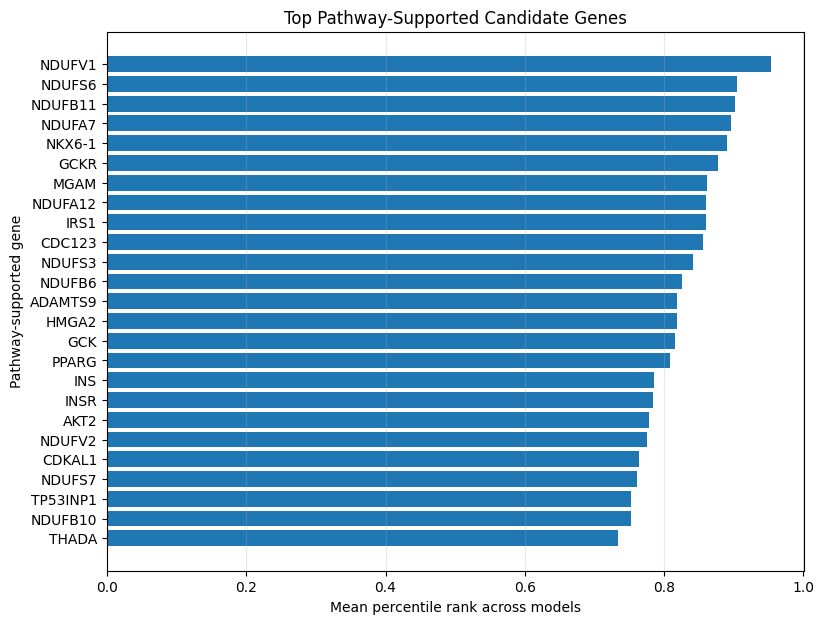

Saved: /content/drive/MyDrive/Project_Protein/model/phase20_pathway_network_validation/figures/phase20_top_pathway_supported_candidate_genes.png


In [13]:
# ============================================================
# FIGURE 4 — TOP PATHWAY-SUPPORTED CANDIDATES
# ============================================================

plot_df = compact_top_pathway_candidates_df.head(25).copy()

plt.figure(figsize=(9, 7))
plt.barh(
    plot_df["gene_symbol"][::-1],
    plot_df["mean_percentile_rank"][::-1]
)
plt.xlabel("Mean percentile rank across models")
plt.ylabel("Pathway-supported gene")
plt.title("Top Pathway-Supported Candidate Genes")
plt.grid(axis="x", alpha=0.3)

out_path = FIGURE_DIR / "phase20_top_pathway_supported_candidate_genes.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

In [14]:
# ============================================================
# MANUSCRIPT-READY SUMMARY TABLES
# ============================================================

manuscript_pathway_top100_df = topn_pathway_df[
    (topn_pathway_df["top_n"] == 100) &
    (topn_pathway_df["pathway"].isin(pathway_order))
].copy()

manuscript_pathway_top100_df = manuscript_pathway_top100_df[[
    "display_name",
    "pathway",
    "observed_overlap",
    "random_mean",
    "fold_enrichment_vs_random",
    "empirical_p",
    "empirical_bh_fdr_within_topn",
    "overlap_genes"
]].sort_values(["pathway", "display_name"])

manuscript_pathway_top100_df = round_numeric_columns(manuscript_pathway_top100_df, 4)

display(manuscript_pathway_top100_df)

save_df(manuscript_pathway_top100_df, RESULT_DIR / "phase20_manuscript_top100_pathway_validation_table.csv")


manuscript_network_df = network_density_df[
    network_density_df["top_n"] == 100
][[
    "display_name",
    "observed_curated_network_edges",
    "random_mean_edges",
    "fold_enrichment_vs_random",
    "empirical_p",
    "empirical_bh_fdr_within_topn",
    "observed_edges"
]].copy()

manuscript_network_df = round_numeric_columns(manuscript_network_df, 4)

display(manuscript_network_df)

save_df(manuscript_network_df, RESULT_DIR / "phase20_manuscript_network_density_table.csv")

,display_name,pathway,observed_overlap,random_mean,fold_enrichment_vs_random,empirical_p,empirical_bh_fdr_within_topn,overlap_genes
2,DNABERT-2 multimodal,Beta_cell_function_development,1,0.8884,1.1256,0.5973,1.0,NKX6-1
37,Genomic-only,Beta_cell_function_development,1,0.8760,1.1416,0.5961,1.0,HNF1B
72,Handcrafted multimodal,Beta_cell_function_development,1,0.8886,1.1254,0.5953,1.0,NKX6-1
107,Protein-only,Beta_cell_function_development,2,0.8656,2.3105,0.2114,1.0,GCK; NKX6-1
7,DNABERT-2 multimodal,Glucose_metabolism_transport,1,0.5830,1.7153,0.4523,1.0,GCKR
42,Genomic-only,Glucose_metabolism_transport,0,0.5928,0.0000,1.0000,1.0,
77,Handcrafted multimodal,Glucose_metabolism_transport,1,0.6092,1.6415,0.4675,1.0,GCKR
112,Protein-only,Glucose_metabolism_transport,2,0.6158,3.2478,0.1284,1.0,GCK; GCKR
12,DNABERT-2 multimodal,Incretin_diabetes_pharmacology,0,0.5556,0.0000,1.0000,1.0,
47,Genomic-only,Incretin_diabetes_pharmacology,0,0.5470,0.0000,1.0000,1.0,


Saved: /content/drive/MyDrive/Project_Protein/model/phase20_pathway_network_validation/results/phase20_manuscript_top100_pathway_validation_table.csv


,display_name,observed_curated_network_edges,random_mean_edges,fold_enrichment_vs_random,empirical_p,empirical_bh_fdr_within_topn,observed_edges
1,DNABERT-2 multimodal,6,1.8597,3.2264,0.1150,0.4598,NDUFA12-NDUFA7; NDUFA7-NDUFB11; NDUFA12-NDUFV1; NDUFA7-NDUFV1; NDUFA12-NDUFB11; NDUFB11-NDUFV1
5,Genomic-only,0,1.8500,0.0000,1.0000,1.0000,
9,Handcrafted multimodal,1,1.8913,0.5287,0.6378,1.0000,NDUFB11-NDUFV1
13,Protein-only,0,1.9920,0.0000,1.0000,1.0000,


Saved: /content/drive/MyDrive/Project_Protein/model/phase20_pathway_network_validation/results/phase20_manuscript_network_density_table.csv


In [15]:
# ============================================================
# MANUSCRIPT-READY WORDING
# ============================================================

# Identify strongest pathway result
best_pathway = topn_pathway_df[
    topn_pathway_df["top_n"] == 100
].sort_values("fold_enrichment_vs_random", ascending=False).head(1)

if not best_pathway.empty:
    best_row = best_pathway.iloc[0]
    best_sentence = (
        f"The strongest Top-100 pathway enrichment was observed for "
        f"{best_row['pathway']} in the {best_row['display_name']} model, "
        f"with {int(best_row['observed_overlap'])} observed genes compared with "
        f"a random expectation of {best_row['random_mean']:.2f}."
    )
else:
    best_sentence = (
        "Top-100 pathway enrichment results were summarized against random baselines."
    )

# Identify best network result
best_network = network_density_df[
    network_density_df["top_n"] == 100
].sort_values("fold_enrichment_vs_random", ascending=False).head(1)

if not best_network.empty:
    net_row = best_network.iloc[0]
    network_sentence = (
        f"For curated network density, the strongest Top-100 result was observed in "
        f"the {net_row['display_name']} model, with "
        f"{int(net_row['observed_curated_network_edges'])} observed curated edges "
        f"compared with a random expectation of {net_row['random_mean_edges']:.2f}."
    )
else:
    network_sentence = (
        "Curated network density was compared against random same-size gene sets."
    )

methods_text = """
To complement external gene-set validation, pathway- and network-level biological validation was performed using curated T2D-relevant modules. The modules represented insulin signalling, beta-cell function and development, insulin secretion, glucose metabolism and transport, incretin and diabetes pharmacology, known T2D/GWAS loci and mitochondrial complex I/OXPHOS biology. For each model, top-ranked genes were compared with these pathway modules at multiple top-N thresholds. Same-size random gene sets sampled from the candidate universe were used to estimate empirical null distributions, and p-values were adjusted using Benjamini--Hochberg correction. A curated biological network was also constructed from pathway-module relationships, and the number of within-module edges among top-ranked genes was compared with random baselines.
""".strip()

results_text = f"""
Pathway-level validation provided a module-based view of the biological signal captured by the rankings. {best_sentence} Curated pathway overlap results were strongest for selected biological themes rather than uniformly significant across all external gene sets. {network_sentence} These analyses support a cautious pathway-level interpretation of the rankings, particularly for mitochondrial/OXPHOS, beta-cell and glucose-regulatory modules, while avoiding overclaiming individual genes as causal T2D drivers.
""".strip()

discussion_text = """
The pathway and network validation reframes the biological interpretation from individual-gene confirmation to module-level plausibility. This is important because disease-gene labels are incomplete and external validation did not show strong global enrichment after multiple-testing correction. Coherent recovery of T2D-relevant modules, especially beta-cell function, glucose regulation and mitochondrial/OXPHOS biology, provides supportive evidence that the models capture biologically meaningful sequence-derived signals. However, these findings should remain hypothesis-generating. The strongest conclusion is not that every top-ranked gene is a confirmed T2D gene, but that the ranking framework recovers interpretable biological modules and highlights candidates for further experimental or literature-based validation.
""".strip()

wording_df = pd.DataFrame([
    {"section": "Methods - Pathway and Network Validation", "text": methods_text},
    {"section": "Results - Pathway and Network Validation", "text": results_text},
    {"section": "Discussion - Module-Level Biological Interpretation", "text": discussion_text}
])

display(wording_df)

save_df(wording_df, RESULT_DIR / "phase20_manuscript_ready_wording.csv")

with open(REPORT_DIR / "phase20_manuscript_ready_wording.md", "w") as f:
    for _, row in wording_df.iterrows():
        f.write(f"## {row['section']}\n\n")
        f.write(row["text"] + "\n\n")

print("Saved manuscript wording.")

,section,text
0,Methods - Pathway and Network Validation,"To complement external gene-set validation, pathway- and network-level biological validation was performed using curated T2D-relevant modules. The modules represented insulin signalling, beta-cell function and development, insulin secretion, glucose metabolism and transport, incretin and diabetes pharmacology, known T2D/GWAS loci and mitochondrial complex I/OXPHOS biology. For each model, top-ranked genes were compared with these pathway modules at multiple top-N thresholds. Same-size random..."
1,Results - Pathway and Network Validation,"Pathway-level validation provided a module-based view of the biological signal captured by the rankings. The strongest Top-100 pathway enrichment was observed for Glucose_metabolism_transport in the Protein-only model, with 2 observed genes compared with a random expectation of 0.62. Curated pathway overlap results were strongest for selected biological themes rather than uniformly significant across all external gene sets. For curated network density, the strongest Top-100 result was observ..."
2,Discussion - Module-Level Biological Interpretation,"The pathway and network validation reframes the biological interpretation from individual-gene confirmation to module-level plausibility. This is important because disease-gene labels are incomplete and external validation did not show strong global enrichment after multiple-testing correction. Coherent recovery of T2D-relevant modules, especially beta-cell function, glucose regulation and mitochondrial/OXPHOS biology, provides supportive evidence that the models capture biologically meaning..."


Saved: /content/drive/MyDrive/Project_Protein/model/phase20_pathway_network_validation/results/phase20_manuscript_ready_wording.csv
Saved manuscript wording.


In [16]:
# ============================================================
# EXPORT EXCEL WORKBOOK
# ============================================================

excel_path = EXCEL_DIR / "phase20_pathway_network_validation_tables.xlsx"

tables = {
    "Pathway_Gene_Sets": pathway_gene_df,
    "Pathway_Coverage": pathway_coverage_df,
    "TopN_Pathway_Enrichment": topn_pathway_df,
    "Pathway_Rank_Tests": pathway_rank_test_df,
    "Network_Edges_All": network_edges_df,
    "Network_Edges_Universe": network_edges_universe_df,
    "Network_Density": network_density_df,
    "All_Gene_Pathway_Annotation": pathway_candidate_df,
    "Top_Pathway_Candidates": compact_top_pathway_candidates_df,
    "Manuscript_Pathway_Top100": manuscript_pathway_top100_df,
    "Manuscript_Network": manuscript_network_df,
    "Wording": wording_df
}

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    for sheet_name, df in tables.items():
        if df is not None and not df.empty:
            df.to_excel(writer, sheet_name=sheet_name[:31], index=False)

print("Saved Excel:", excel_path)

Saved Excel: /content/drive/MyDrive/Project_Protein/model/phase20_pathway_network_validation/excel/phase20_pathway_network_validation_tables.xlsx


In [17]:
# ============================================================
# FINAL SUMMARY
# ============================================================

print("=== PHASE 20 COMPLETE ===")

print("\nPathway coverage:")
display(pathway_coverage_df)

print("\nTop-100 pathway validation:")
display(manuscript_pathway_top100_df)

print("\nPathway rank-distribution tests:")
display(pathway_rank_test_df)

print("\nNetwork density:")
display(manuscript_network_df)

print("\nTop pathway-supported candidates:")
display(compact_top_pathway_candidates_df.head(50))

print("\nWording:")
display(wording_df)

print("\nFigures:")
for p in sorted(FIGURE_DIR.glob("*.png")):
    print(p)

print("\nResults:")
for p in sorted(RESULT_DIR.glob("*.csv")):
    print(p)

print("\nExcel:")
for p in sorted(EXCEL_DIR.glob("*.xlsx")):
    print(p)

print("\nReports:")
for p in sorted(REPORT_DIR.glob("*")):
    print(p)

=== PHASE 20 COMPLETE ===

Pathway coverage:


,pathway,n_pathway_genes,n_in_candidate_universe,genes_in_universe,coverage_rate
0,Beta_cell_function_development,20,16,CACNA1D; GAD1; GCK; GLIS3; HNF1A; HNF1B; HNF4A; INS; ISL1; MTNR1B; NEUROD1; NKX6-1; PAX4; PCSK1; PDX1; SLC30A8,0.8000
1,Glucose_metabolism_transport,14,11,AKT2; G6PC2; GCK; GCKR; HK1; INSR; IRS1; IRS2; SLC2A2; SLC5A1; SLC5A2,0.7857
2,Incretin_diabetes_pharmacology,10,10,ABCC8; DPP4; GCK; GIPR; GLP1R; INSR; KCNJ11; MGAM; PPARG; SLC5A2,1.0000
3,Insulin_secretion_KATP_Ca,10,9,ABCC8; CACNA1D; GCK; GIPR; GLP1R; INS; KCNJ11; PCSK1; SLC30A8,0.9000
4,Insulin_signalling,11,8,AKT2; GRB14; INSR; IRS1; IRS2; PIK3R1; PPARG; TBC1D4,0.7273
5,Known_T2D_GWAS_loci,34,32,ADAMTS9; ADCY5; CAMK1D; CDC123; CDKAL1; CDKN2B; DUSP9; FTO; GCK; GCKR; GIPR; GLIS3; GRB14; HHEX; HMGA2; IGF2BP2; INSR; IRS1; JAZF1; KCNJ11; KCNQ1; MAEA; MTNR1B; NOTCH2; PPARG; PROX1; SLC30A8; TCF7L2; THADA; TP53INP1; TSPAN8; WFS1,0.9412
6,Mitochondrial_complex_I_OXPHOS,35,34,NDUFA1; NDUFA10; NDUFA11; NDUFA12; NDUFA13; NDUFA2; NDUFA3; NDUFA5; NDUFA6; NDUFA7; NDUFA8; NDUFA9; NDUFB1; NDUFB10; NDUFB11; NDUFB2; NDUFB3; NDUFB4; NDUFB5; NDUFB6; NDUFB7; NDUFB8; NDUFB9; NDUFS1; NDUFS2; NDUFS3; NDUFS4; NDUFS5; NDUFS6; NDUFS7; NDUFS8; NDUFV1; NDUFV2; NDUFV3,0.9714



Top-100 pathway validation:


,display_name,pathway,observed_overlap,random_mean,fold_enrichment_vs_random,empirical_p,empirical_bh_fdr_within_topn,overlap_genes
2,DNABERT-2 multimodal,Beta_cell_function_development,1,0.8884,1.1256,0.5973,1.0,NKX6-1
37,Genomic-only,Beta_cell_function_development,1,0.8760,1.1416,0.5961,1.0,HNF1B
72,Handcrafted multimodal,Beta_cell_function_development,1,0.8886,1.1254,0.5953,1.0,NKX6-1
107,Protein-only,Beta_cell_function_development,2,0.8656,2.3105,0.2114,1.0,GCK; NKX6-1
7,DNABERT-2 multimodal,Glucose_metabolism_transport,1,0.5830,1.7153,0.4523,1.0,GCKR
42,Genomic-only,Glucose_metabolism_transport,0,0.5928,0.0000,1.0000,1.0,
77,Handcrafted multimodal,Glucose_metabolism_transport,1,0.6092,1.6415,0.4675,1.0,GCKR
112,Protein-only,Glucose_metabolism_transport,2,0.6158,3.2478,0.1284,1.0,GCK; GCKR
12,DNABERT-2 multimodal,Incretin_diabetes_pharmacology,0,0.5556,0.0000,1.0000,1.0,
47,Genomic-only,Incretin_diabetes_pharmacology,0,0.5470,0.0000,1.0000,1.0,



Pathway rank-distribution tests:


...


Top pathway-supported candidates:


,gene_symbol,true_label,consensus_rank,mean_percentile_rank,best_rank,n_curated_pathways,curated_pathways,relabel_audit_priority,external_evidence_strength
0,NDUFV1,0,22,0.95374,28,1,Mitochondrial_complex_I_OXPHOS,high,single_source
1,NDUFS6,1,90,0.90512,120,1,Mitochondrial_complex_I_OXPHOS,,
2,NDUFB11,1,95,0.90125,55,1,Mitochondrial_complex_I_OXPHOS,,
3,NDUFA7,1,107,0.89584,28,1,Mitochondrial_complex_I_OXPHOS,,
4,NKX6-1,1,115,0.89003,23,1,Beta_cell_function_development,,
5,GCKR,1,131,0.87687,6,2,Glucose_metabolism_transport; Known_T2D_GWAS_loci,,
6,MGAM,1,156,0.86150,130,1,Incretin_diabetes_pharmacology,,
7,NDUFA12,0,158,0.85997,30,1,Mitochondrial_complex_I_OXPHOS,high,single_source
8,IRS1,1,159,0.85983,117,3,Glucose_metabolism_transport; Insulin_signalling; Known_T2D_GWAS_loci,,
9,CDC123,1,168,0.85582,48,1,Known_T2D_GWAS_loci,,



Wording:


,section,text
0,Methods - Pathway and Network Validation,"To complement external gene-set validation, pathway- and network-level biological validation was performed using curated T2D-relevant modules. The modules represented insulin signalling, beta-cell function and development, insulin secretion, glucose metabolism and transport, incretin and diabetes pharmacology, known T2D/GWAS loci and mitochondrial complex I/OXPHOS biology. For each model, top-ranked genes were compared with these pathway modules at multiple top-N thresholds. Same-size random..."
1,Results - Pathway and Network Validation,"Pathway-level validation provided a module-based view of the biological signal captured by the rankings. The strongest Top-100 pathway enrichment was observed for Glucose_metabolism_transport in the Protein-only model, with 2 observed genes compared with a random expectation of 0.62. Curated pathway overlap results were strongest for selected biological themes rather than uniformly significant across all external gene sets. For curated network density, the strongest Top-100 result was observ..."
2,Discussion - Module-Level Biological Interpretation,"The pathway and network validation reframes the biological interpretation from individual-gene confirmation to module-level plausibility. This is important because disease-gene labels are incomplete and external validation did not show strong global enrichment after multiple-testing correction. Coherent recovery of T2D-relevant modules, especially beta-cell function, glucose regulation and mitochondrial/OXPHOS biology, provides supportive evidence that the models capture biologically meaning..."



Figures:
/content/drive/MyDrive/Project_Protein/model/phase20_pathway_network_validation/figures/phase20_DNABERT-2_multimodal_top100_observed_vs_random_pathway_overlap.png
/content/drive/MyDrive/Project_Protein/model/phase20_pathway_network_validation/figures/phase20_top100_curated_network_density.png
/content/drive/MyDrive/Project_Protein/model/phase20_pathway_network_validation/figures/phase20_top100_pathway_enrichment_heatmap.png
/content/drive/MyDrive/Project_Protein/model/phase20_pathway_network_validation/figures/phase20_top_pathway_supported_candidate_genes.png

Results:
/content/drive/MyDrive/Project_Protein/model/phase20_pathway_network_validation/results/phase20_all_genes_with_pathway_annotations.csv
/content/drive/MyDrive/Project_Protein/model/phase20_pathway_network_validation/results/phase20_curated_network_edges_all.csv
/content/drive/MyDrive/Project_Protein/model/phase20_pathway_network_validation/results/phase20_curated_network_edges_in_universe.csv
/content/drive/MyDr

In [18]:
display(pathway_coverage_df)

display(manuscript_pathway_top100_df)

display(pathway_rank_test_df[[
    "display_name",
    "pathway",
    "n_pathway_genes_in_universe",
    "delta_mean_score",
    "median_rank_pathway",
    "median_rank_non_pathway",
    "mannwhitney_score_greater_p",
    "score_bh_fdr_global"
]])

display(manuscript_network_df)

display(compact_top_pathway_candidates_df.head(50))

,pathway,n_pathway_genes,n_in_candidate_universe,genes_in_universe,coverage_rate
0,Beta_cell_function_development,20,16,CACNA1D; GAD1; GCK; GLIS3; HNF1A; HNF1B; HNF4A; INS; ISL1; MTNR1B; NEUROD1; NKX6-1; PAX4; PCSK1; PDX1; SLC30A8,0.8000
1,Glucose_metabolism_transport,14,11,AKT2; G6PC2; GCK; GCKR; HK1; INSR; IRS1; IRS2; SLC2A2; SLC5A1; SLC5A2,0.7857
2,Incretin_diabetes_pharmacology,10,10,ABCC8; DPP4; GCK; GIPR; GLP1R; INSR; KCNJ11; MGAM; PPARG; SLC5A2,1.0000
3,Insulin_secretion_KATP_Ca,10,9,ABCC8; CACNA1D; GCK; GIPR; GLP1R; INS; KCNJ11; PCSK1; SLC30A8,0.9000
4,Insulin_signalling,11,8,AKT2; GRB14; INSR; IRS1; IRS2; PIK3R1; PPARG; TBC1D4,0.7273
5,Known_T2D_GWAS_loci,34,32,ADAMTS9; ADCY5; CAMK1D; CDC123; CDKAL1; CDKN2B; DUSP9; FTO; GCK; GCKR; GIPR; GLIS3; GRB14; HHEX; HMGA2; IGF2BP2; INSR; IRS1; JAZF1; KCNJ11; KCNQ1; MAEA; MTNR1B; NOTCH2; PPARG; PROX1; SLC30A8; TCF7L2; THADA; TP53INP1; TSPAN8; WFS1,0.9412
6,Mitochondrial_complex_I_OXPHOS,35,34,NDUFA1; NDUFA10; NDUFA11; NDUFA12; NDUFA13; NDUFA2; NDUFA3; NDUFA5; NDUFA6; NDUFA7; NDUFA8; NDUFA9; NDUFB1; NDUFB10; NDUFB11; NDUFB2; NDUFB3; NDUFB4; NDUFB5; NDUFB6; NDUFB7; NDUFB8; NDUFB9; NDUFS1; NDUFS2; NDUFS3; NDUFS4; NDUFS5; NDUFS6; NDUFS7; NDUFS8; NDUFV1; NDUFV2; NDUFV3,0.9714


,display_name,pathway,observed_overlap,random_mean,fold_enrichment_vs_random,empirical_p,empirical_bh_fdr_within_topn,overlap_genes
2,DNABERT-2 multimodal,Beta_cell_function_development,1,0.8884,1.1256,0.5973,1.0,NKX6-1
37,Genomic-only,Beta_cell_function_development,1,0.8760,1.1416,0.5961,1.0,HNF1B
72,Handcrafted multimodal,Beta_cell_function_development,1,0.8886,1.1254,0.5953,1.0,NKX6-1
107,Protein-only,Beta_cell_function_development,2,0.8656,2.3105,0.2114,1.0,GCK; NKX6-1
7,DNABERT-2 multimodal,Glucose_metabolism_transport,1,0.5830,1.7153,0.4523,1.0,GCKR
42,Genomic-only,Glucose_metabolism_transport,0,0.5928,0.0000,1.0000,1.0,
77,Handcrafted multimodal,Glucose_metabolism_transport,1,0.6092,1.6415,0.4675,1.0,GCKR
112,Protein-only,Glucose_metabolism_transport,2,0.6158,3.2478,0.1284,1.0,GCK; GCKR
12,DNABERT-2 multimodal,Incretin_diabetes_pharmacology,0,0.5556,0.0000,1.0000,1.0,
47,Genomic-only,Incretin_diabetes_pharmacology,0,0.5470,0.0000,1.0000,1.0,


,display_name,pathway,n_pathway_genes_in_universe,delta_mean_score,median_rank_pathway,median_rank_non_pathway,mannwhitney_score_greater_p,score_bh_fdr_global
0,DNABERT-2 multimodal,Beta_cell_function_development,16,-0.05385,1127.0,900.5,0.87095,0.89667
1,DNABERT-2 multimodal,Glucose_metabolism_transport,11,0.03772,911.0,903.0,0.26403,0.64493
2,DNABERT-2 multimodal,Incretin_diabetes_pharmacology,10,0.03889,552.5,904.5,0.25246,0.64493
3,DNABERT-2 multimodal,Insulin_secretion_KATP_Ca,9,-0.04005,1129.0,903.0,0.72289,0.86382
4,DNABERT-2 multimodal,Insulin_signalling,8,0.00685,767.0,903.5,0.46984,0.65778
5,DNABERT-2 multimodal,Known_T2D_GWAS_loci,32,0.01388,915.0,903.5,0.33730,0.64493
6,DNABERT-2 multimodal,Mitochondrial_complex_I_OXPHOS,34,0.04492,665.5,907.5,0.09267,0.64493
7,Genomic-only,Beta_cell_function_development,16,0.01262,681.5,905.5,0.24312,0.64493
8,Genomic-only,Glucose_metabolism_transport,11,-0.00058,777.0,905.0,0.39572,0.64493
9,Genomic-only,Incretin_diabetes_pharmacology,10,0.01583,702.0,905.5,0.25951,0.64493


,display_name,observed_curated_network_edges,random_mean_edges,fold_enrichment_vs_random,empirical_p,empirical_bh_fdr_within_topn,observed_edges
1,DNABERT-2 multimodal,6,1.8597,3.2264,0.1150,0.4598,NDUFA12-NDUFA7; NDUFA7-NDUFB11; NDUFA12-NDUFV1; NDUFA7-NDUFV1; NDUFA12-NDUFB11; NDUFB11-NDUFV1
5,Genomic-only,0,1.8500,0.0000,1.0000,1.0000,
9,Handcrafted multimodal,1,1.8913,0.5287,0.6378,1.0000,NDUFB11-NDUFV1
13,Protein-only,0,1.9920,0.0000,1.0000,1.0000,


,gene_symbol,true_label,consensus_rank,mean_percentile_rank,best_rank,n_curated_pathways,curated_pathways,relabel_audit_priority,external_evidence_strength
0,NDUFV1,0,22,0.95374,28,1,Mitochondrial_complex_I_OXPHOS,high,single_source
1,NDUFS6,1,90,0.90512,120,1,Mitochondrial_complex_I_OXPHOS,,
2,NDUFB11,1,95,0.90125,55,1,Mitochondrial_complex_I_OXPHOS,,
3,NDUFA7,1,107,0.89584,28,1,Mitochondrial_complex_I_OXPHOS,,
4,NKX6-1,1,115,0.89003,23,1,Beta_cell_function_development,,
5,GCKR,1,131,0.87687,6,2,Glucose_metabolism_transport; Known_T2D_GWAS_loci,,
6,MGAM,1,156,0.86150,130,1,Incretin_diabetes_pharmacology,,
7,NDUFA12,0,158,0.85997,30,1,Mitochondrial_complex_I_OXPHOS,high,single_source
8,IRS1,1,159,0.85983,117,3,Glucose_metabolism_transport; Insulin_signalling; Known_T2D_GWAS_loci,,
9,CDC123,1,168,0.85582,48,1,Known_T2D_GWAS_loci,,
